# Insights Module

In [ ]:
import json
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from utils.formatters import load_json
from utils.gcs import load_from_gcs, list_from_gcs

## Functions

In [5]:
import re
from tqdm import tqdm

def remove_duplicates_dicts(data):
    seen = set()
    unique = []
    for item in data:
        item_str = json.dumps(item, sort_keys=True)  # Convert dict to string
        if item_str not in seen:
            seen.add(item_str)
            unique.append(item)
    return unique

def download_from_gcs(
    bucket_name: str,
    folder_prefix: str,
    filename: str,
    id_field: str,
    text_field: str
    ):
    # Get list of files
    blobnames = list_from_gcs(bucket_name, folder_prefix, filename)

    assert len(blobnames) > 0, f"No files found!"

    # Download from GCS
    all_data = []

    def find_date(text):
        # Regular expression to match YYYY-MM-DD format
        date_pattern = r'\b\d{4}-\d{2}-\d{2}\b'

        # Extract date
        match = re.search(date_pattern, text)
        return match.group()
    
    for blob in tqdm(blobnames, desc="Downloading blobs", unit="blob", total=len(blobnames)):
        data = load_from_gcs(bucket_name, blob_name=blob)
        filter_data = [{'id': x[id_field], 'date': find_date(blob), 'text': x[text_field]} for x in data]
        all_data += filter_data

    # Remove Duplicates
    data = remove_duplicates_dicts(all_data)
    
    return data

## Summary Statistics

In [6]:
# Load Data
transcripts_helene = load_json(f"data/hurricane-helene_transcripts_cleaned.json")
transcripts_milton = load_json(f"data/hurricane-milton_transcripts_cleaned.json")

commentThreads_helene = load_json(f"data/hurricane-helene_commentThreads_cleaned.json")
commentThreads_milton = load_json(f"data/hurricane-milton_commentThreads_cleaned.json")

commentThreadsreplies_helene = load_json(f"data/hurricane-helene_commentThreadsreplies_cleaned.json")
commentThreadsreplies_milton = load_json(f"data/hurricane-milton_commentThreadsreplies_cleaned.json")

In [7]:
# No of data collected
print(f"Transcripts Helene: {len(transcripts_helene)}")
print(f"Transcripts Milton: {len(transcripts_milton)}")

print(f"Comments Helene: {len(commentThreads_helene) + len(commentThreadsreplies_helene)}")
print(f"Comments Milton: {len(commentThreads_milton) + len(commentThreadsreplies_milton)}")

Transcripts Helene: 1545
Transcripts Milton: 918
Comments Helene: 441497
Comments Milton: 309857


In [8]:
# Mean length of text
bucket_name = 'youtube-data-api'
folder = 'youtube-index'

query = 'hurricane milton'
folder_prefix = f"{folder}/{'-'.join(query.split()).lower()}"

milton_transcripts = download_from_gcs(filename = 'transcripts.json', id_field = 'videoId', text_field = 'transcript', bucket_name = bucket_name, folder_prefix = folder_prefix)
milton_commentThreads = download_from_gcs(filename = 'commentThreads.json', id_field = 'id', text_field = 'textOriginal', bucket_name = bucket_name, folder_prefix = folder_prefix)
milton_commentThreadsreplies = download_from_gcs(filename = 'commentThreadsreplies.json', id_field = 'id', text_field = 'textOriginal', bucket_name = bucket_name, folder_prefix = folder_prefix)

query = 'hurricane helene'
folder_prefix = f"{folder}/{'-'.join(query.split()).lower()}"

helene_transcripts = download_from_gcs(filename = 'transcripts.json', id_field = 'videoId', text_field = 'transcript', bucket_name = bucket_name, folder_prefix = folder_prefix)
helene_commentThreads = download_from_gcs(filename = 'commentThreads.json', id_field = 'id', text_field = 'textOriginal', bucket_name = bucket_name, folder_prefix = folder_prefix)
helene_commentThreadsreplies = download_from_gcs(filename = 'commentThreadsreplies.json', id_field = 'id', text_field = 'textOriginal', bucket_name = bucket_name, folder_prefix = folder_prefix)

print(f"Transcripts Helene: {np.mean([len(i['text']) for i in helene_transcripts])}")
print(f"Transcripts Milton: {np.mean([len(i['text']) for i in milton_transcripts])}")
print(f"Comments Helene: {np.mean([len(i['text']) for i in helene_commentThreads] + [len(i['text']) for i in helene_commentThreadsreplies])}")
print(f"Comments Milton: {np.mean([len(i['text']) for i in milton_commentThreads] + [len(i['text']) for i in milton_commentThreadsreplies])}")

Transcripts Helene: 4013.4245954692556
Transcripts Milton: 5294.261437908497
Comments Helene: 125.07484988572969
Comments Milton: 117.65795512123334


In [ ]:
# Combine all data
df_milton = pd.DataFrame(
    [{'date': i['date'], 'id':i['id'], 'type':'transcript'} for i in milton_transcripts] +
    [{'date': i['date'], 'id':i['id'], 'type':'comment'} for i in milton_commentThreads] + 
    [{'date': i['date'], 'id':i['id'], 'type':'reply'} for i in milton_commentThreadsreplies]
)

df_helene = pd.DataFrame(
    [{'date': i['date'], 'id':i['id'], 'type':'transcript'} for i in helene_transcripts] +
    [{'date': i['date'], 'id':i['id'], 'type':'comment'} for i in helene_commentThreads] +
    [{'date': i['date'], 'id':i['id'], 'type':'reply'} for i in helene_commentThreadsreplies]
)

In [10]:
# Export
with pd.ExcelWriter('data/youtube_index_raw.xlsx', engine='xlsxwriter') as writer:
    df_milton.to_excel(writer, sheet_name='milton', index=False)
    df_helene.to_excel(writer, sheet_name='helene', index=False)

In [ ]:
# Reload Data
df_milton = pd.read_excel('data/youtube_index_raw.xlsx', sheet_name='milton')
df_helene = pd.read_excel('data/youtube_index_raw.xlsx', sheet_name='helene')

# Convert date to datetime
df_milton['date'] = pd.to_datetime(df_milton['date'])
df_helene['date'] = pd.to_datetime(df_helene['date'])

# Aggregate data
df_milton_agg = df_milton.groupby(['date', 'type2'])['id'].count().reset_index().fillna(0)
df_helene_agg = df_helene.groupby(['date', 'type2'])['id'].count().reset_index().fillna(0)

In [25]:
df_milton_agg = df_milton.groupby(['date', 'type2'])['id'].count().reset_index().fillna(0)
df_milton_agg = df_milton_agg.pivot(index="date", columns="type2", values="id").reset_index().fillna(0)
df_milton_agg.columns.name = None
df_milton_agg.rename(columns={"comment": "comment_count", "transcript": "transcript_count"}, inplace=True)

df_helene_agg = df_helene.groupby(['date', 'type2'])['id'].count().reset_index().fillna(0)
df_helene_agg = df_helene_agg.pivot(index="date", columns="type2", values="id").reset_index().fillna(0)
df_helene_agg.columns.name = None
df_helene_agg.rename(columns={"comment": "comment_count", "transcript": "transcript_count"}, inplace=True)

df_helene_agg

,date,comment_count,transcript_count
0,2024-09-15,48.0,1.0
1,2024-09-16,627.0,4.0
2,2024-09-17,160.0,1.0
3,2024-09-19,303.0,0.0
4,2024-09-22,487.0,2.0
5,2024-09-23,2446.0,15.0
6,2024-09-24,3778.0,64.0
7,2024-09-25,2613.0,16.0
8,2024-09-26,8045.0,52.0
9,2024-09-27,21887.0,82.0


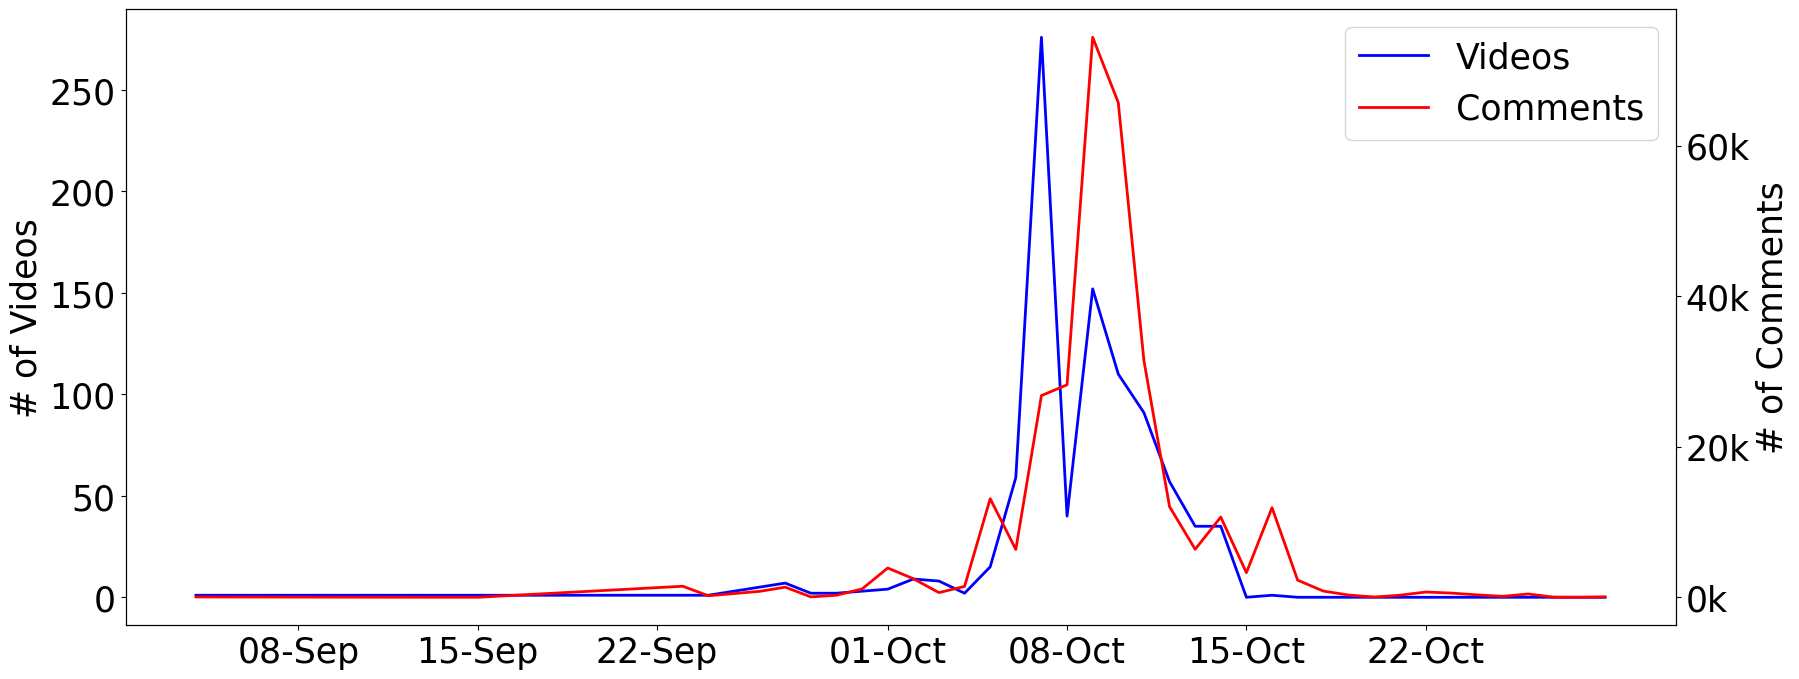

In [ ]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(20, 8))

# Plot first line on the primary Y-axis
sns.lineplot(data=df_milton_agg, x='date', y='transcript_count', ax=ax1, color="blue", label="Videos", linewidth=2)
ax1.set_ylabel("# of Videos")
ax1.tick_params(axis='y')

# Create a secondary Y-axis
ax2 = ax1.twinx()

# Plot second line on the secondary Y-axis
sns.lineplot(data=df_milton_agg, x='date', y='comment_count', ax=ax2, color="red", label="Comments", linewidth=2)
ax2.set_ylabel("# of Comments")
ax2.tick_params(axis='y')

# Format ax2 y-ticks to thousands
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Add legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc="upper right")
ax2.get_legend().remove()

# Set Date Format for x-Ticks
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))  # DD-Mon format

# Hide x-axis name
ax1.set_xlabel('')

# Rotate x-Ticks
plt.xticks(rotation=45)  # If using x-axis dates

# Increase all font sizes
plt.rcParams.update({'font.size': 25})

plt.show()